In [93]:
import pennylane as qml
import torch
from distributions import *
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torch.nn.functional import softmax
import numpy as np
from matplotlib import pyplot as plt
import os
import ot
import time
import csv


In [94]:
# Version 0.47

# NEW:  
# Cost depending on the distance between x and y 
# qubits to be measured can be chosen on the circuit settings 
# added scaling variational parameters e.g. R(a*theta) 

# TO DO
# for image inferencing, add weights, higher weights to sections with more distance between images
# dependent and independent ansatz layers
# maybe layerwise?
# remove implicit declarations e.g. using len(x_data_train[0]) when defining the circuit

In [95]:

# ----------entanglers-----------
def entangler_daisychain(wires):
    num_wires = len(wires)
    for i in range(num_wires):
        qml.CZ(wires=[wires[i], wires[(i + 1) % num_wires]])

def entangler_line(wires):
    num_wires = len(wires)
    for i in range(num_wires-1):
        qml.CZ(wires=[wires[i], wires[(i + 1) ]])
#-------------------------------      

def encoder (pars, wires, entangler):
    num_wires = len(wires)
    xy_counter = 0
    for i in range(len(pars)):    
        if xy_counter%2:
            qml.RY(pars[i], wires = wires[i%num_wires])
        else:
            qml.RX(pars[i], wires = wires[i%num_wires])
        if (i+1) % num_wires == 0 and i+1 != len(pars):
            entangler(wires)
            xy_counter += 1

def ansatz(params, p, wires): # p is number of ansatz layers
    for k in range(p):
        for i, wire in enumerate(wires):
            qml.Rot(params[0, i, k], params[1, i, k], params[2, i, k], wires=wire)
        num_wires = len(wires)
        for i in range(num_wires):
            qml.CNOT(wires=[wires[i], wires[(i + 1) % num_wires]])

def set_up_circuit(circuit_type, n_qubits, n_copies, n_ansatzlayers_body, n_reuploads, n_ansatzlayers_tail, n_lines = 1, entangler_type = 'l', measurement_qubits = 'all'):
    
    #creates a string with the setings information
    info  = 'circ_type_' + circuit_type + '-' + f'n_qubits_{n_qubits}-n_copies_{n_copies}-n_ansatzlayers_body{n_ansatzlayers_body}-n_ansatzlayers_tail{n_ansatzlayers_tail}-n_reuploads_{n_reuploads}-n_lines_{n_lines}' + '-entangler_type_'+ entangler_type + '-measurement_qubits_' + measurement_qubits

    n_wires_per_copy = int(n_qubits/n_copies)
    
    if entangler_type == 'dc':
        entangler = entangler_daisychain    
    elif entangler_type == 'l':
        entangler = entangler_line
    
    if n_wires_per_copy == 1:
        entangler = entangler_line
        shuffle_in_copies = False
            
    if n_qubits % n_copies > 0:
        raise ValueError('n_qubits has to be divisible by n_copies')

    if measurement_qubits == 'all':
        meas_q = range(n_qubits)
    elif measurement_qubits == 'first':
        meas_q = range(1)
    else:
        meas_q = measurement_qubits


######################################################################################################################################

    if circuit_type == "v2":    
    # For a better understanding of the options, check the schematic bellow
    
    # circuit_type: currently only v2 in this verison
    # n_qubits: self explainatory
    # n_copies: number of parallel copies 
    # n_ansatzlayers_body: number of ansatz layers in between the "x lines" and "y lines" 
    # n_reuploads: number of times the inputs x and y are put in the quantum circuit 
    # n_ansatzlayers_tail: number of ansatz laters after the reuploads 
    # n_lines: number of "lines" of an input in between ansatz layers 
    # entangler_type: entangling circuit between lines
    # measurement_qubits: can be  "all", "first", or a list of qubit indices


#       Example x and y data
#  ---- ---- ---- ----    ---- ---- ---- ----
# | x1 | x3 | x5 | x7 |  | y1 | y3 | y5 | y7 |
#  ---- ---- ---- ----    ---- ---- ---- ----
# | x2 | x4 | x6 | x8 |  | y2 | y4 | y6 | y8 | 
#  ---- ---- ---- ----    ---- ---- ---- ----
# Note: data formated as a matrces for visual convenience
            

#                                                                                 n_reuploads:      reupload_1                                                                               reupload_2           n_ansatzlayers_tail    
#                      ________________________________________________________________________________/\____________________________________________________________________  __________________/\_______________  ______/|_____
#                     /                                                                                                                                                      \/                                   \/             \
#                                 n_lines        n_ansatzlayers_body
#                             _______/\______      _____/\_____
#                            /               \    /            \
#           /          /      ___          ___      _________      ___          ___      _________      ___          ___      _________      ___          ___      _________                                          _________     __
#           |          | ----|x1 |----q---|x3 |----|         |----|y1 |----q---|y3 |----|         |----|x5 |----q---|x7 |----|         |----|y5 |----q---|y7 |----|         |----                                 ---|         |---|/X|     
#           | n_copies |      ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |                                        |         |    --         
#           |  copy_1 <               |            |         |             |            |         |             |            |         |             |            |         |     ...                         ...    |         |                             ...
#           |          |      ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |                                        |         |    __              
#           |          | ----|x2 |----b---|x4 |----|         |----|y2 |----b---|y4 |----|         |----|x6 |----b---|x8 |----|         |----|y6 |----b---|y8 |----|         |----                                 ---|         |---|/X|
#           |          \      ---          ---     |         |     ---          ---     |         |     ---          ---     |         |     ---          ---     |         |                                        |         |    --      
# n_qubits <                                       |         |                          |         |                          |         |                          |         |     ...                         ...    |         |                      
#           |          /      ___          ___     |         |     ___          ___     |         |     ___          ___     |         |     ___          ___     |         |                                        |         |    __    
#           |          | ----|x1 |----q---|x3 |----|         |----|y1 |----q---|y3 |----|         |----|x5 |----q---|x7 |----|         |----|y5 |----q---|y7 |----|         |----                                 ---|         |---|/X|            
#           |          |      ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |                                        |         |    --
#           |  copy_2 <               |            |         |             |            |         |             |            |         |             |            |         |     ...                         ...    |         |              
#           |          |      ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |                                        |         |    __
#           |          | ----|x1 |----b---|x4 |----|         |----|y2 |----b---|y4 |----|         |----|x6 |----b---|x8 |----|         |----|y5 |----b---|y8 |----|         |----                                 ---|         |---|/X|
#           \          \      ---          ---      ---------      ---          ---      ---------      ---          ---      ---------      ---          ---      ---------                                          ---------     --    
#                                   \_ _/                                                                                                                                                                                         \_ _/ 
#                                     V                                                                                                                                                                                             V   
#                                entangler_type                                                                                                                                                                                measurements
        
        # Calculates the number of parameters at each secion of the curcuit
        array_len_per_encoder = int(n_wires_per_copy * n_lines)
        n_encoders = int(len(x_data_train[0])/array_len_per_encoder)
        thetas_body_shape = [n_reuploads, n_encoders*2, 3, n_qubits, n_ansatzlayers_body]
        thetas_tail_shape = [3, n_qubits, n_ansatzlayers_tail]
        n_thetas_body = np.prod(thetas_body_shape)
        n_thetas_tail = np.prod(thetas_tail_shape)
        n_thetas = n_thetas_body + n_thetas_tail

        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def circuit(thetas, x, y):

            # Separates the vatiational parameters into body and tail ansatz parameters 
            thetas_body = thetas[:n_thetas_body]
            thetas_body = thetas_body.reshape(thetas_body_shape)
            thetas_tail = thetas[n_thetas_body:]
            thetas_tail = thetas_tail.reshape(thetas_tail_shape)

            # Reshapes x and y deppending on if they are a single or a batch of inputs
            if x.dim() == 1:
                x = x.reshape([n_encoders, array_len_per_encoder])
                y = y.reshape([n_encoders, array_len_per_encoder])
            else:
                batch_size = len(x[0])
                x = x.reshape([n_encoders, array_len_per_encoder, batch_size])
                y = y.reshape([n_encoders, array_len_per_encoder, batch_size])
            
            # Builds the quantum circuit
            for i in range(n_reuploads):
                for j in range(n_encoders):
                    
                    # Encode part of data x in n_copies
                    for k in range(n_copies):
                        encoder (x[j], wires=range(n_wires_per_copy*k, n_wires_per_copy*(k+1)), entangler=entangler)
                        
                    # Ansatz layers after encoding part of x   
                    ansatz(thetas_body[i][j*2], n_ansatzlayers_body, wires=range(n_qubits))
                    
                    # Encode part of data y in n_copies
                    for k in range(n_copies):
                        encoder (y[j], wires=range(n_wires_per_copy*k, n_wires_per_copy*(k+1)), entangler=entangler)

                    # Ansatz layers after encoding part of y   
                    ansatz(thetas_body[i][j*2+1], n_ansatzlayers_body, wires=range(n_qubits))
                    
            # Ansatz layers at the end of the circuit
            ansatz (thetas_tail, n_ansatzlayers_tail, wires=range(n_qubits))     
            
            return [qml.expval(qml.PauliZ(i))for i in meas_q] 



##########################################################################################################################################

    if circuit_type == "v3":

    # Similar to v2 but with multiple parameters per rotation onm the x input encodings, e.g. Rx(a*x), here a are refered as mult thetas
        
    # For a better understanding of the options, check the schematic bellow
    
    # circuit_type: currently only v2 in this verison
    # n_qubits: self explainatory
    # n_copies: number of parallel copies 
    # n_ansatzlayers_body: number of ansatz layers in between the "x lines" and "y lines" 
    # n_reuploads: number of times the inputs x and y are put in the quantum circuit 
    # n_ansatzlayers_tail: number of ansatz laters after the reuploads 
    # n_lines: number of "lines" of an input in between ansatz layers 
    # entangler_type: entangling circuit between lines
    # measurement_qubits: can be  "all", "first", or a list of qubit indices


#       Example x and y data
#  ---- ---- ---- ----    ---- ---- ---- ----
# | x1 | x3 | x5 | x7 |  | y1 | y3 | y5 | y7 |
#  ---- ---- ---- ----    ---- ---- ---- ----
# | x2 | x4 | x6 | x8 |  | y2 | y4 | y6 | y8 | 
#  ---- ---- ---- ----    ---- ---- ---- ----
# Note: data formated as a matrces for visual convenience
            

#                                                                                 n_reuploads:      reupload_1                                                                               reupload_2           n_ansatzlayers_tail    
#                      ________________________________________________________________________________/\____________________________________________________________________  __________________/\_______________  ______/|_____
#                     /                                                                                                                                                      \/                                   \/             \
#                                 n_lines        n_ansatzlayers_body
#                             _______/\______      _____/\_____
#                            /               \    /            \
#           /          /      ___          ___      _________      ___          ___      _________      ___          ___      _________      ___          ___      _________                                          _________     __
#           |          | ----|x1 |----q---|x3 |----|         |----|y1 |----q---|y3 |----|         |----|x5 |----q---|x7 |----|         |----|y5 |----q---|y7 |----|         |----                                 ---|         |---|/X|     
#           | n_copies |      ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |                                        |         |    --         
#           |  copy_1 <               |            |         |             |            |         |             |            |         |             |            |         |     ...                         ...    |         |                             ...
#           |          |      ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |                                        |         |    __              
#           |          | ----|x2 |----b---|x4 |----|         |----|y2 |----b---|y4 |----|         |----|x6 |----b---|x8 |----|         |----|y6 |----b---|y8 |----|         |----                                 ---|         |---|/X|
#           |          \      ---          ---     |         |     ---          ---     |         |     ---          ---     |         |     ---          ---     |         |                                        |         |    --      
# n_qubits <                                       |         |                          |         |                          |         |                          |         |     ...                         ...    |         |                      
#           |          /      ___          ___     |         |     ___          ___     |         |     ___          ___     |         |     ___          ___     |         |                                        |         |    __    
#           |          | ----|x1 |----q---|x3 |----|         |----|y1 |----q---|y3 |----|         |----|x5 |----q---|x7 |----|         |----|y5 |----q---|y7 |----|         |----                                 ---|         |---|/X|            
#           |          |      ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |     ---     |    ---     |         |                                        |         |    --
#           |  copy_2 <               |            |         |             |            |         |             |            |         |             |            |         |     ...                         ...    |         |              
#           |          |      ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |     ___     |    ___     |         |                                        |         |    __
#           |          | ----|x1 |----b---|x4 |----|         |----|y2 |----b---|y4 |----|         |----|x6 |----b---|x8 |----|         |----|y5 |----b---|y8 |----|         |----                                 ---|         |---|/X|
#           \          \      ---          ---      ---------      ---          ---      ---------      ---          ---      ---------      ---          ---      ---------                                          ---------     --    
#                                   \_ _/                                                                                                                                                                                         \_ _/ 
#                                     V                                                                                                                                                                                             V   
#                                entangler_type                                                                                                                                                                                measurements
        
        # Calculates the number of parameters at each secion of the curcuit
        
        array_len_per_encoder = int(n_wires_per_copy * n_lines)
        n_encoders = int(len(x_data_train[0])/array_len_per_encoder)

        n_thetas_mult = len(x_data_train[0]) * n_reuploads * n_copies
        
        thetas_mult_shape = [n_reuploads, n_encoders, n_copies, array_len_per_encoder] 
        
        thetas_body_shape = [n_reuploads, n_encoders*2, 3, n_qubits, n_ansatzlayers_body]
        thetas_tail_shape = [3, n_qubits, n_ansatzlayers_tail]
        
        n_thetas_body = np.prod(thetas_body_shape)
        n_thetas_tail = np.prod(thetas_tail_shape)
        n_thetas = n_thetas_body + n_thetas_tail + n_thetas_mult

        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def circuit(thetas, x, y):

            # Separates the vatiational parameters into body and tail ansatz parameters 
            thetas_body = thetas[:n_thetas_body]
            thetas_body = thetas_body.reshape(thetas_body_shape)
            
            thetas_tail = thetas[n_thetas_body : n_thetas_body + n_thetas_tail]
            thetas_tail = thetas_tail.reshape(thetas_tail_shape)

            thetas_mult = thetas[n_thetas_body + n_thetas_tail:]
            thetas_mult = thetas_mult.reshape(thetas_mult_shape)
            
            # Reshapes x and y deppending on if they are a single or a batch of inputs

            x_dims = x.dim()
            if x_dims == 1:
                x = x.reshape([n_encoders, array_len_per_encoder])
                y = y.reshape([n_encoders, array_len_per_encoder])
            else:
                batch_size = len(x[0])
                x = x.reshape([n_encoders, array_len_per_encoder, batch_size])
                y = y.reshape([n_encoders, array_len_per_encoder, batch_size])
            
            # Builds the quantum circuit
            for i in range(n_reuploads):
                
                for j in range(n_encoders):
                    
                    # Encode part of data x in n_copies
                    for k in range(n_copies):

                        if x_dims == 1:
                            axb =  x[j] * thetas_mult[i][j][k]
                            encoder (axb, wires=range(n_wires_per_copy*k, n_wires_per_copy*(k+1)), entangler=entangler)
                        else:
                            axb =  x[j].transpose(0,1) * thetas_mult[i][j][k]
                            encoder (axb.transpose(0,1), wires=range(n_wires_per_copy*k, n_wires_per_copy*(k+1)), entangler=entangler)
                        
                    # Ansatz layers after encoding part of x   
                    ansatz(thetas_body[i][j*2], n_ansatzlayers_body, wires=range(n_qubits))
                    
                    # Encode part of data y in n_copies
                    for k in range(n_copies):
                        encoder (y[j], wires=range(n_wires_per_copy*k, n_wires_per_copy*(k+1)), entangler=entangler)

                    # Ansatz layers after encoding part of y   
                    ansatz(thetas_body[i][j*2+1], n_ansatzlayers_body, wires=range(n_qubits))
                    
            # Ansatz layers at the end of the circuit
            ansatz (thetas_tail, n_ansatzlayers_tail, wires=range(n_qubits))     
            
            return [qml.expval(qml.PauliZ(i))for i in meas_q] 
            
        return circuit, n_thetas, info

        

        
                                                                                                                                                                                   

In [96]:
# writig to file
def file_dump(line,name):
    with open(name,'a') as f: #####   ADD HERE PATH
        w=csv.writer(f,delimiter=',')
        w.writerow(line)

# To parition input images into patches of a given window size
def windows_inds (data_dims, w_dims, o):
    # data_dims : dimensions of the input image (though flattened in this code)
    # w_dims: dimensions of the window 
    # o: number of overlaping pixels in adjacent windoes
    inds = torch.arange(data_dims[0]*data_dims[1])
    inds = inds.reshape(data_dims)
    
    k_0 = (data_dims[0]- w_dims[0])/(w_dims[0]-o) + 1
    k_1 = (data_dims[1]- w_dims[1])/(w_dims[1]-o) + 1
    
    if k_0.is_integer() and k_1.is_integer() == False:
        raise ValueError('window and overlap values do not cover the whole image')
    
    win_inds = []
    for i in range(int(k_0)):
        for j in range(int(k_1)):
            u = (w_dims[0] - o)*i
            d = u + w_dims[0]
            l = (w_dims[1] - o)*j
            r = l + w_dims[1]
            win_inds.append(inds[u : d][:,l : r].flatten())
    
    return torch.stack(win_inds)
    
# partitions each image from the dataset into a smaller pieces from a moving window
def windows_data (data, data_dims, w_dims, o):
    w_inds = windows_inds (data_dims, w_dims, o)
    w_data = []
    for d in data:
         w_data.append(d[w_inds])
    return torch.concatenate(w_data)
         
# Average expectation value from a list of measurements
def ev_mean(x):
    return torch.mean(torch.stack(x), dim = 0)

# Mean squared error
def mse (x_data, y_data):
    return  torch.mean((x_data - y_data)**2, dim = 1)
    
# rescales values with respect to the distance between inputs, higher r_rate lead to less rescaling (unless distance is 0)
def t_rescaling (t, dists, r_rate):
    return (t-1)*(1-torch.exp(-dists * r_rate)) + 1

def plot_pairs(x, y, dim1=0, dim2=1, save_path=None, colors=None):
    if colors is None:
        colors = ['blue', 'red']  # Default colors
    plt.scatter(x[:, dim1], x[:, dim2], color=colors[0], alpha=0.7, label='Source (x)')
    plt.scatter(y[:, dim1], y[:, dim2], color=colors[1], alpha=0.7, label='Target (y)')
    plt.xlabel(f'Dimension {dim1}')
    plt.ylabel(f'Dimension {dim2}')
    plt.title(f'OT Projection on Plane ({dim1}, {dim2})')
    plt.legend()
    plt.grid()

# Load the dataset

In [101]:
# Ensure save directories exist
dataset_name = 'uniform_to_spiral'  

# dataset_name = 'mnist_downscaled_28x28'  


save_path = f'data/{dataset_name}/'
os.makedirs(save_path + 'optimal_thetas/', exist_ok=True)
os.makedirs(save_path + 'plots/', exist_ok=True)
os.makedirs(save_path + 'dataset/', exist_ok=True)

In [102]:
# #save
# x_data, y_data = uniform_to_random_transformation(dim=8, scaling_A = 0.6, scaling_b = 0.1, frac_inter=0.2)

# torch.save(x_data, save_path+"/dataset/x_data.pt")
# torch.save(y_data, save_path+"/dataset/y_data.pt")

In [312]:
train_size = 512
test_size = 256
offset = 0


# training data
x_data_train = torch.load(save_path+"dataset/x_data.pt",weights_only=True)[offset : train_size + offset]
y_data_train = torch.load(save_path+"dataset/y_data.pt",weights_only=True)[offset : train_size + offset]

# test data
x_data_test = torch.load(save_path+"dataset/x_data.pt",weights_only=True)[train_size + offset : train_size + test_size + offset]
y_data_test = torch.load(save_path+"dataset/y_data.pt",weights_only=True)[train_size + offset : train_size + test_size + offset]


In [100]:
# Use this cell to partition images (flattened) in a dataset by windows

# Dimension of the images
data_dims = [128, 128]

# Dimensions of the windows
w_dims = [4,4]

# Overlap between windows
o = -8

x_data_train = windows_data(x_data_train, data_dims, w_dims, o)
y_data_train = windows_data(y_data_train, data_dims, w_dims, o)

x_data_test  = windows_data(x_data_test, data_dims, w_dims, o)
y_data_test = windows_data(y_data_test, data_dims, w_dims, o)


IndexError: index 2 is out of bounds for dimension 0 with size 2

In [313]:
# Custom dataset class
class XYDataset(Dataset):
    def __init__(self, x_data, y_data):
        assert len(x_data) == len(y_data), "x_data and y_data must have the same number of samples."
        self.x_data = x_data
        self.y_data = y_data

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        return self.x_data[idx], self.y_data[idx]

# DataLoader
dataset_train = XYDataset(x_data_train, y_data_train)
dataloader_train = DataLoader(dataset_train, batch_size=128, shuffle=True)

dataset_test = XYDataset(x_data_test, y_data_test)
dataloader_test = DataLoader(dataset_test, batch_size=256, shuffle=True)

# Fetch a batch
x_batch, y_batch = next(iter(dataloader_train))
print(f"Batch : x_batch shape = {x_batch.shape}, y_batch shape = {y_batch.shape}")

Batch : x_batch shape = torch.Size([128, 2]), y_batch shape = torch.Size([128, 2])


In [105]:
len(x_data_train)

512

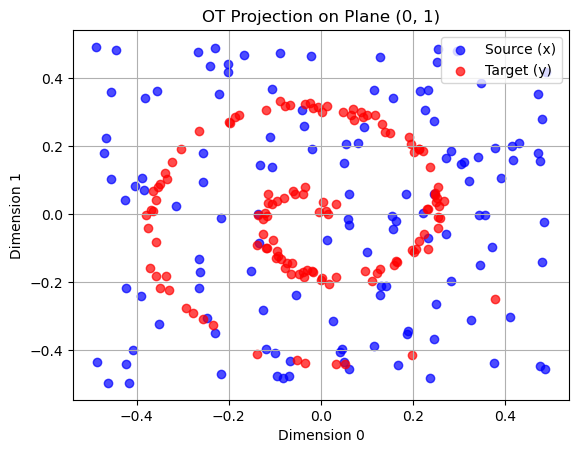

In [106]:
dim1, dim2 = 0, 1
plot_pairs(x_batch, y_batch, dim1=dim1, dim2=dim2)

# Training

In [320]:
# Circuit parameters

circuit_type = "v3"
n_qubits = 2
n_copies = 2
n_ansatzlayers_body = 3
n_reuploads = 15
n_ansatzlayers_tail = 3
n_lines = 2
entangler_type = 'l' 
measurement_qubits = 'all'

circuit, n_thetas, info = set_up_circuit(circuit_type, n_qubits, n_copies, n_ansatzlayers_body, n_reuploads, n_ansatzlayers_tail, n_lines, entangler_type, measurement_qubits)

device = 'cpu'

In [321]:
thetas = torch.rand(n_thetas, requires_grad=True, device=device)
# thetas = torch.rand(n_thetas,device=device)*1
# thetas.requires_grad_(True)

In [322]:
draw_circuit = qml.draw(circuit)
print(draw_circuit(thetas, x_data_train[0], y_data_train[0]))

0: ──RX(-0.24)──RY(0.13)──Rot(0.55,0.66,0.75)─╭●─╭X──Rot(0.81,0.00,0.55)─╭●─╭X──Rot(0.09,0.05,0.03)
1: ──RX(-0.23)──RY(0.01)──Rot(0.81,0.67,0.11)─╰X─╰●──Rot(0.16,0.37,0.27)─╰X─╰●──Rot(0.37,0.26,0.67)

──╭●─╭X──RX(0.23)──RY(0.17)──Rot(0.09,0.77,0.34)─╭●─╭X──Rot(0.41,0.11,0.22)─╭●─╭X
──╰X─╰●──RX(0.23)──RY(0.17)──Rot(0.77,0.23,0.51)─╰X─╰●──Rot(0.14,0.00,0.83)─╰X─╰●

───Rot(0.50,0.97,0.17)─╭●─╭X──RX(-0.00)──RY(0.18)──Rot(0.75,0.75,0.56)─╭●─╭X──Rot(0.91,0.97,0.73)─╭●
───Rot(0.62,0.32,0.63)─╰X─╰●──RX(-0.16)──RY(0.17)──Rot(0.81,0.82,0.03)─╰X─╰●──Rot(0.08,0.93,0.98)─╰X

──╭X──Rot(0.68,0.41,0.36)─╭●─╭X──RX(0.23)──RY(0.17)──Rot(0.77,0.01,0.68)─╭●─╭X──Rot(0.08,0.87,0.17)
──╰●──Rot(0.81,0.84,0.75)─╰X─╰●──RX(0.23)──RY(0.17)──Rot(0.45,0.18,0.96)─╰X─╰●──Rot(0.14,0.28,0.35)

──╭●─╭X──Rot(0.31,0.67,0.51)─╭●─╭X──RX(-0.22)──RY(0.41)──Rot(0.41,0.87,0.70)─╭●─╭X
──╰X─╰●──Rot(0.72,0.11,0.29)─╰X─╰●──RX(-0.29)──RY(0.22)──Rot(0.15,0.95,0.36)─╰X─╰●

───Rot(0.20,0.70,0.86)─╭●─╭X──Rot(0.09,0.60,0.32)─╭●─╭X──RX(0.2

In [336]:
# Optimization parameters

n_epochs = 400
alpha = 0.8
beta = 0.2
r_rate = 2000 # used for the rescaling of t's (see t_rescaling), the larger the less pronaunced the rescaling  

opt = torch.optim.Adam([thetas], lr=0.01)

loss_history = []

In [337]:
# Training loop

for epoch in tqdm(range(n_epochs)):
    epoch_total = 0.0

    for x_batch, y_batch in dataloader_train:
        # Zero the gradients for the batch
        opt.zero_grad()
        
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        x_batch_t = torch.transpose(x_batch, 0, 1)
        y_batch_t = torch.transpose(y_batch, 0, 1)

        t = 2*torch.rand(len(x_batch), device=device)-0.5 # in the range [-0.5, 1.5] for a sine function with period 4, 

        # this is use for calculating the distance from x and y and rescale the cost accordingly
        dists = mse(x_batch, y_batch)
        t_res = t_rescaling(t, dists, r_rate)

        # this is the target of Q(x,t*y + x(1-t)), for t=0: Q(x,x)=0, t=1: Q(x,y)=1, t<0: Q<0, t>1: Q<1
        cost_value = torch.sin(torch.pi/2 * t_res) 

        mid_term = (ev_mean(circuit(thetas, x_batch_t, y_batch_t*t + x_batch_t*(1-t))) - cost_value)**2

        min_term = (ev_mean(circuit(thetas, x_batch_t, y_batch_t)) - 1)**2
        
        # Combine terms with weights 
        losses = alpha * min_term + beta * mid_term 

        batch_loss = torch.mean(losses)  
        batch_loss.backward()  # Compute gradients
        opt.step()  # Update parameters
        
        epoch_total += batch_loss.item()
    
    epoch_mean = epoch_total/len(dataloader_train)  
    loss_history.append(epoch_mean)
    
    # Print epoch progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}")
        print(f"  Loss:  {loss_history[-1]:.4f}\n")
        

# torch.save(thetas, save_path + 'optimal_thetas/' + 'optimal_thetas_' + info + '.pt')

  1%|▌                                          | 5/400 [00:12<16:35,  2.52s/it]

Epoch 5/400
  Loss:  0.0135



  2%|█                                         | 10/400 [00:24<15:59,  2.46s/it]

Epoch 10/400
  Loss:  0.0069



  4%|█▌                                        | 15/400 [00:37<15:50,  2.47s/it]

...

Epoch 20/400
  Loss:  0.0060



  6%|██▋                                       | 25/400 [01:02<15:24,  2.46s/it]

Epoch 25/400
  Loss:  0.0051



  6%|██▋                                       | 25/400 [01:03<15:47,  2.53s/it]


KeyboardInterrupt: 

In [366]:
# Save the optimized prameters 
version = "-v3"
torch.save(thetas, save_path + 'optimal_thetas/' + 'optimal_thetas_' + info + version + '.pt')

In [339]:
# write the circuit setings and performance data to a csv file
file_dump([info + version, loss_history[-1]], save_path + 'optimal_thetas/' + f'performance_database.csv') 

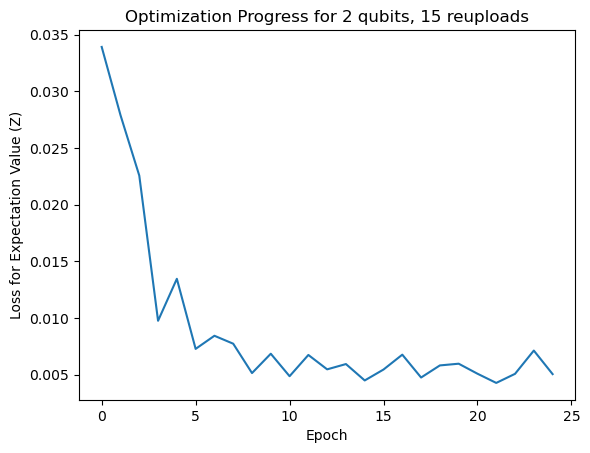

In [340]:
# print(f'Eval score for (x,y): {ev_mean(circuit(thetas, x_data_train[0], y_data_train[0]))}, and (x,x): {ev_mean(circuit(thetas, x_data_train[0], x_data_train[0])).item()}')

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss for Expectation Value (Z)")
plt.title(f'Optimization Progress for {n_qubits} qubits, {n_reuploads} reuploads')
# plt.savefig(save_path + 'plots/' + f'loss_train_n_qubits{n_qubits}_n_reuploads{n_reuploads}.png')
plt.show()

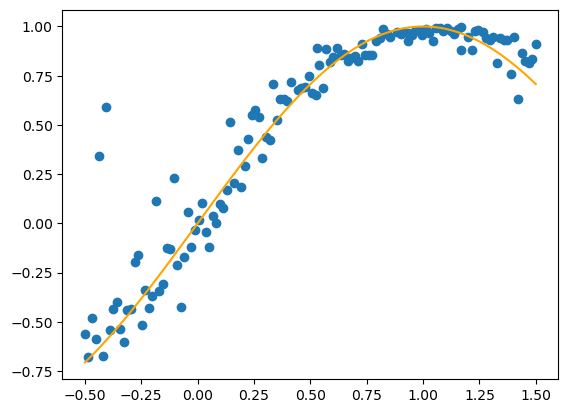

In [341]:
t = torch.linspace(-0.5,1.5, len(x_batch), device=device)

dists = mse(x_batch, y_batch)
t_res = t_rescaling(t, dists, r_rate)

res = ev_mean(circuit(thetas, x_batch.transpose(1, 0), y_batch.transpose(1, 0)*t + x_batch.transpose(1, 0)*(1-t)))
cost_value = torch.sin(torch.pi/2*t) 

plt.scatter(t_res.detach().cpu().numpy(),res.detach().cpu().numpy())
plt.plot(t.detach().cpu().numpy(),cost_value.detach().cpu().numpy(), color ='orange')


# Inference

In [370]:
#loading optimal thetas
version = '-v3_worksgreat'
thetas = torch.load( save_path + 'optimal_thetas/' + 'optimal_thetas_' + info + version + '.pt')

/tmp/ipykernel_4856/4214947188.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  thetas = torch.load( save_path + 'optimal_thetas/' + 'optimal_thetas_' + info + version + 

In [371]:
x_test, y_true = next(iter(dataloader_test))

x_star = x_test.clone().detach().requires_grad_(True)
frozen_thetas = thetas.clone().detach().requires_grad_(False).to(device)



eval_loss_history = []
x_star_history = []  # List to store x_star values over epochs


In [372]:
# Use a separate optimizer for x*
opt_x = torch.optim.Adam([x_star], lr=0.05)

In [373]:
eval_n_epochs = 200

for epoch in tqdm(range(eval_n_epochs)):
    opt_x.zero_grad()
    
    # Forward pass for a single instance
    loss  =   (ev_mean(circuit(frozen_thetas, x_test.transpose(1,0), x_star.transpose(1,0))) - 1) ** 2 # -circuit(frozen_thetas, x_inst, x_star_inst)    
    
    # Compute the average loss over the batch
    batch_loss = loss.mean()
    
    # Backward pass
    batch_loss.backward()
    
    # Update the parameters
    opt_x.step()
    
    # Store the current value of x_star
    x_star_history.append(x_star.detach().clone())  # Detach and clone to avoid modifying the original tensor
    
    # Track the loss (using the average loss for the batch)
    eval_loss_history.append(batch_loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{eval_n_epochs}, Loss: {batch_loss.item():.4f}")

M = ot.dist(x_star, y_true)
a = torch.ones(x_star.shape[0]) / x_star.shape[0]
loss = ot.emd2(a, a, M)
print(f"Optimal Transport Loss: {loss}")
x_star_history_tens = torch.stack(x_star_history)  # Shape: (eval_n_epochs, batch_size, data_dim)

  6%|██▎                                       | 11/200 [00:02<00:37,  5.09it/s]

Epoch 10/200, Loss: 0.0237


 10%|████▍                                     | 21/200 [00:04<00:40,  4.44it/s]

Epoch 20/200, Loss: 0.0126


 16%|██████▌                                   | 31/200 [00:06<00:33,  4.99it/s]

...

Epoch 180/200, Loss: 0.0003


 95%|██████████████████████████████████████▉  | 190/200 [00:38<00:01,  5.04it/s]

Epoch 190/200, Loss: 0.0003


100%|█████████████████████████████████████████| 200/200 [00:40<00:00,  4.89it/s]

Epoch 200/200, Loss: 0.0003
Optimal Transport Loss: 0.00413737166672945


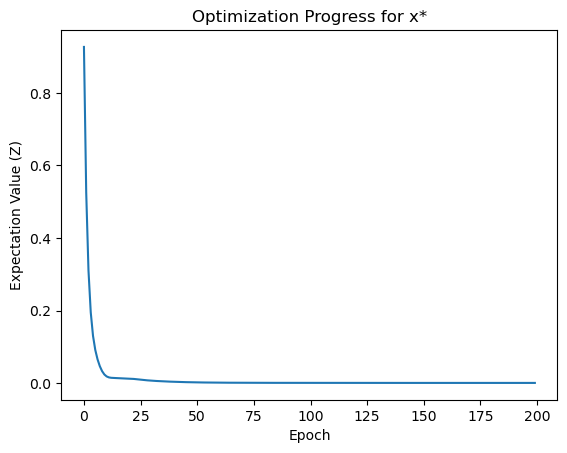

In [374]:
plt.plot(eval_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Expectation Value (Z)")
plt.title("Optimization Progress for x*")
# plt.savefig(save_path + 'plots/' + f'loss_eval_n_qubits{n_qubits}_n_reuploads{n_reuploads}.png')
plt.show()

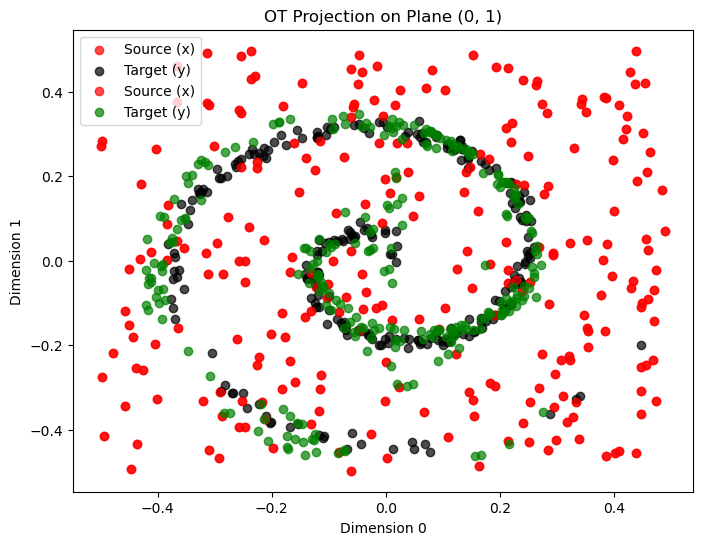

In [375]:
# x,y = next(iter(dataloader))
dim1, dim2 = 0,1
plt.figure(figsize=(8, 6))
plot_pairs(x_test, y_true, dim1=dim1, dim2=dim2, colors=['red', 'black'])

# for i in range(x_star_history_tens.shape[1]):  # Iterate over each instance in the batch
#     plt.scatter(
#         x_star_history_tens[:, i, dim1].cpu(),
#         x_star_history_tens[:, i, dim2].cpu(),
#         c='grey', s=10, alpha=0.1
#     )
plot_pairs(x_test, x_star.detach().cpu(), dim1=dim1, dim2=dim2, colors=['red', 'green'])

# plt.savefig(save_path + 'plots/' + f'mapping_n_qubits{n_qubits}_n_reuploads{n_reuploads}.png')
plt.show()

In [376]:
i=11
in_x = x_test[i].reshape(4,4).detach().cpu()
out_x = x_star[i].reshape(4,4).detach().cpu()


fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(in_x, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(out_x, cmap='gray')
ax[1].set_title('Reconstructed Image')
plt.show()

RuntimeError: shape '[4, 4]' is invalid for input of size 2

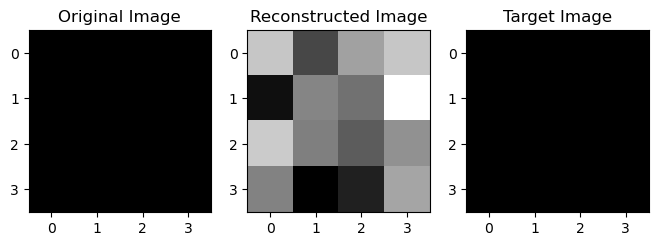

In [75]:
i=3
dim1= 4
dim2 = 4
in_x = x_test[i].reshape(dim1,dim2).detach().cpu()
out_x = x_star[i].reshape(dim1,dim2).detach().cpu()
target_x = y_true[i].reshape(dim1,dim2).detach().cpu()

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(in_x, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(out_x, cmap='gray')
ax[1].set_title('Reconstructed Image')
ax[2].imshow(target_x, cmap='gray')
ax[2].set_title('Target Image')
plt.show()

In [76]:
print(torch.sum((in_x-target_x)**2).flatten())
print(torch.sum((out_x-target_x)**2).flatten())



tensor([0.])
tensor([0.0154])


# Inference for images

In [1006]:
#full data for inference
x_data_test_full = torch.load(save_path+"dataset/x_data.pt",weights_only=True)[train_size + offset : train_size + test_size + offset]
y_data_test_full = torch.load(save_path+"dataset/y_data.pt",weights_only=True)[train_size + offset : train_size + test_size + offset]

dataset_test_full = XYDataset(x_data_test_full, y_data_test_full)
dataloader_test_full = DataLoader(dataset_test_full, batch_size=1, shuffle=True)

In [1007]:
# Load saved optimal thetas

version = '-window_4x4-v3'
thetas = torch.load( save_path + 'optimal_thetas/' + 'optimal_thetas_' + info + version + '.pt')

/tmp/ipykernel_2990394/394497793.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  thetas = torch.load( save_path + 'optimal_thetas/' + 'optimal_thetas_' + info + version 

In [710]:
x_test, y_true = next(iter(dataloader_test_full))


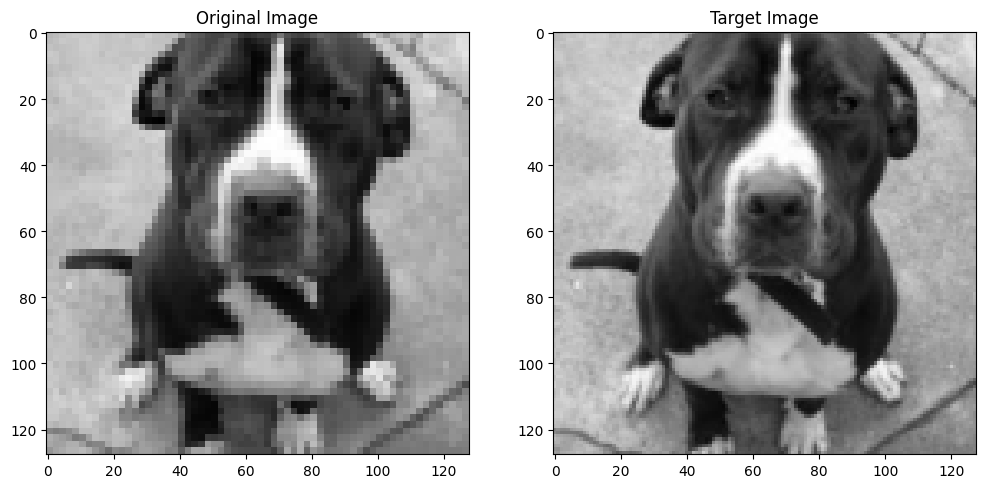

In [1008]:

# x_star = x_test.clone().detach().requires_grad_(True) 

x_star = x_test.clone().detach() + torch.rand([1,len(x_test[0])], device=device) * 0.2 - 0.1
x_star.requires_grad_(True)

# x_star = torch.rand([1,len(x_test[0])], requires_grad=True, device=device)

frozen_thetas = thetas.clone().detach().requires_grad_(False).to(device)

eval_loss_history = []
x_star_history = []  # List to store x_star values over epochs


dim1 = data_dims[0]
dim2 = data_dims[1]

i=0

in_x = x_test[i].reshape(dim1,dim2).detach().cpu()
out_x = x_star[i].reshape(dim1,dim2).detach().cpu()
target_x = y_true[i].reshape(dim1,dim2).detach().cpu()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(in_x, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(target_x, cmap='gray')
ax[1].set_title('Target Image')
plt.show()

In [1009]:
# Change the overlap to have better spatial coherence
o = 2

x_test_windows  = windows_data(x_test, data_dims, w_dims, o)


In [1010]:
# Use a separate optimizer for x*
opt_x = torch.optim.Adam([x_star], lr=0.01)

In [1011]:
eval_n_epochs = 100

for epoch in tqdm(range(eval_n_epochs)):
    opt_x.zero_grad()

    x_star_windows = windows_data(x_star, data_dims, w_dims, o)

    
    # Forward pass for a single instance
    loss  =   (ev_mean(circuit(frozen_thetas, x_test_windows.transpose(1,0), x_star_windows.transpose(1,0))) - 1) ** 2 # -circuit(frozen_thetas, x_inst, x_star_inst)    
    
    # Compute the average loss over the batch
    batch_loss = loss.mean()
    
    # Backward pass
    batch_loss.backward()
    
    # Update the parameters
    opt_x.step()
    
    # Store the current value of x_star
    x_star_history.append(x_star.detach().clone())  # Detach and clone to avoid modifying the original tensor
    
    # Track the loss (using the average loss for the batch)
    eval_loss_history.append(batch_loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{eval_n_epochs}, Loss: {batch_loss.item():.4f}")

M = ot.dist(x_star, y_true)
a = torch.ones(x_star.shape[0]) / x_star.shape[0]
loss = ot.emd2(a, a, M)
print(f"Optimal Transport Loss: {loss}")
x_star_history_tens = torch.stack(x_star_history)  # Shape: (eval_n_epochs, batch_size, data_dim)

 10%|████▏                                     | 10/100 [00:44<06:32,  4.36s/it]

Epoch 10/100, Loss: 0.0117


 20%|████████▍                                 | 20/100 [01:31<06:05,  4.57s/it]

Epoch 20/100, Loss: 0.0074


 30%|████████████▌                             | 30/100 [02:15<05:20,  4.59s/it]

...

Epoch 80/100, Loss: 0.0015


 90%|█████████████████████████████████████▊    | 90/100 [06:43<00:44,  4.42s/it]

Epoch 90/100, Loss: 0.0014


100%|█████████████████████████████████████████| 100/100 [07:27<00:00,  4.48s/it]

Epoch 100/100, Loss: 0.0014
Optimal Transport Loss: 27.07568359375


In [1012]:
# eval_n_epochs = 100

# for epoch in tqdm(range(eval_n_epochs)):
#     opt_x.zero_grad()

#     x_star_windows = windows_data(x_star, data_dims, w_dims, o)

    
#     # Forward pass for a single instance
#     loss  =   (ev_mean(circuit(frozen_thetas, x_test_windows.transpose(1,0), x_star_windows.transpose(1,0))) - 1) ** 2 # -circuit(frozen_thetas, x_inst, x_star_inst)    


    
#     dists = mse(x_star_windows, x_test_windows)
#     soft_dists = softmax(dists, dim = 0)

#     batch_loss = torch.sum(loss * soft_dists)

    
#     # Compute the average loss over the batch
#     batch_loss = loss.mean()
    
#     # Backward pass
#     batch_loss.backward()
    
#     # Update the parameters
#     opt_x.step()
    
#     # Store the current value of x_star
#     x_star_history.append(x_star.detach().clone())  # Detach and clone to avoid modifying the original tensor
    
#     # Track the loss (using the average loss for the batch)
#     eval_loss_history.append(batch_loss.item())
    
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{eval_n_epochs}, Loss: {batch_loss.item():.4f}")

# M = ot.dist(x_star, y_true)
# a = torch.ones(x_star.shape[0]) / x_star.shape[0]
# loss = ot.emd2(a, a, M)
# print(f"Optimal Transport Loss: {loss}")
# x_star_history_tens = torch.stack(x_star_history)  # Shape: (eval_n_epochs, batch_size, data_dim)

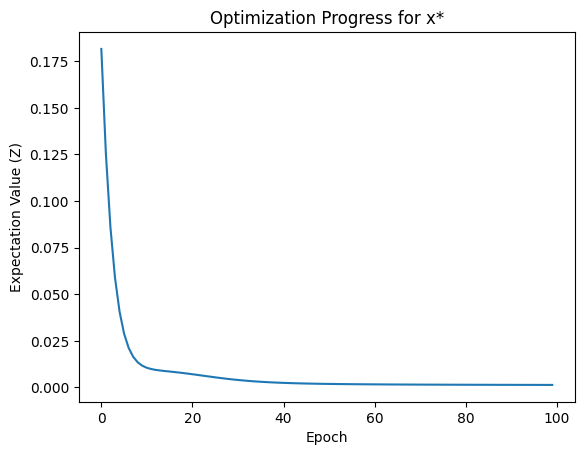

In [1013]:
plt.plot(eval_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Expectation Value (Z)")
plt.title("Optimization Progress for x*")
# plt.savefig(save_path + 'plots/' + f'loss_eval_n_qubits{n_qubits}_n_reuploads{n_reuploads}.png')
plt.show()

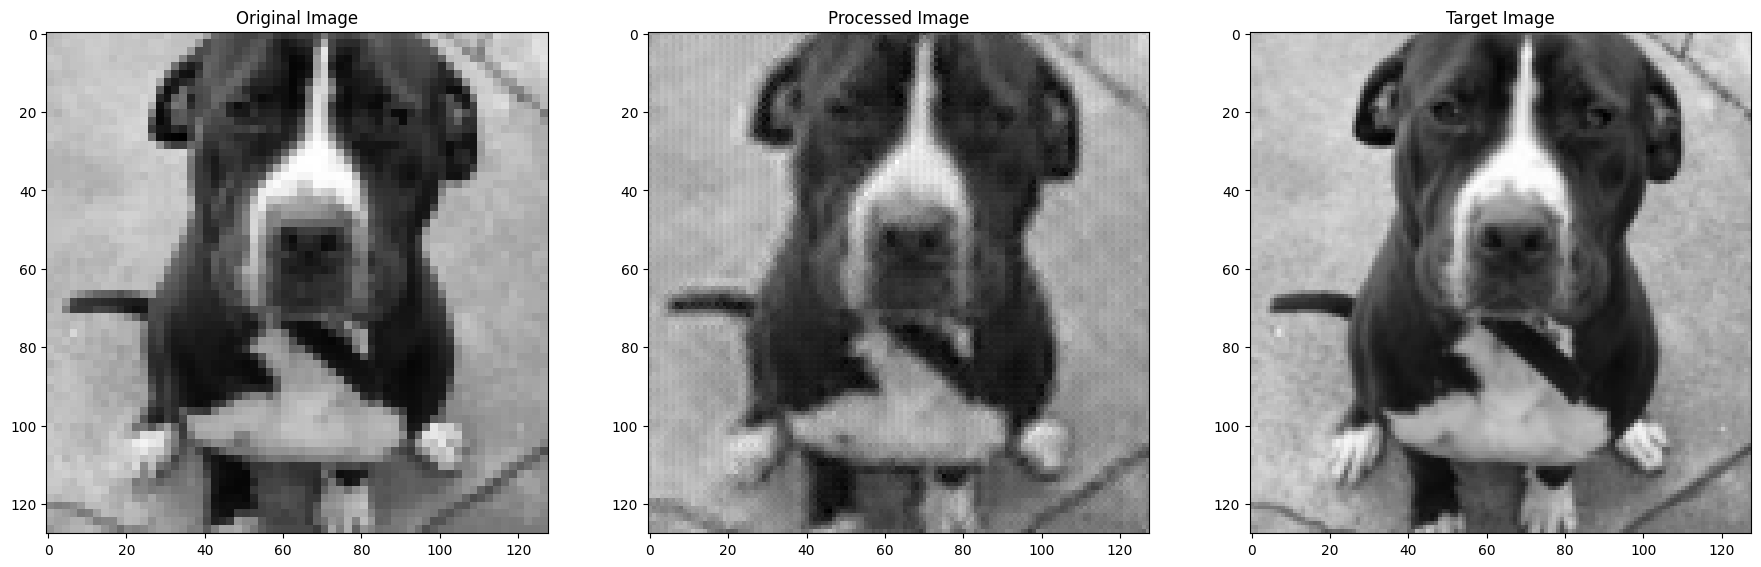

In [1014]:
i=0

in_x = x_test[i].reshape(dim1,dim2).detach().cpu()
out_x = x_star[i].reshape(dim1,dim2).detach().cpu()
target_x = y_true[i].reshape(dim1,dim2).detach().cpu()

fig, ax = plt.subplots(1, 3, figsize=(22, 11))
ax[0].imshow(in_x, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(out_x, cmap='gray')
ax[1].set_title('Processed Image')
ax[2].imshow(target_x, cmap='gray')
ax[2].set_title('Target Image')
plt.show()

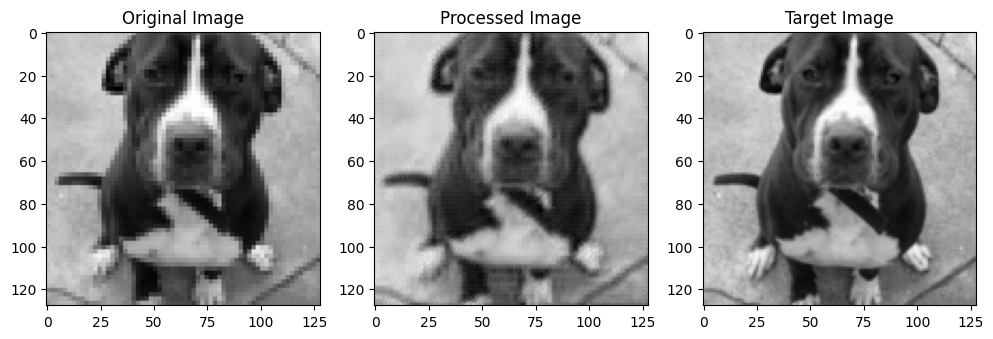

In [979]:
i=0

in_x = x_test[i].reshape(dim1,dim2).detach().cpu()
out_x = x_star[i].reshape(dim1,dim2).detach().cpu()
target_x = y_true[i].reshape(dim1,dim2).detach().cpu()

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(in_x, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(out_x, cmap='gray')
ax[1].set_title('Processed Image')
ax[2].imshow(target_x, cmap='gray')
ax[2].set_title('Target Image')
plt.show()
